Loaded studentInfo: 32,593 rows
Overall dropout rate: 31.2%

C1: Encoding features...
  Rows after dropping missing values: 25,714  (6,879 dropped)
  Dropout rate in model dataset: 20.8%
  Features: ['gender_enc', 'age_enc', 'edu_enc', 'imd_enc', 'disab_enc', 'num_of_prev_attempts', 'studied_credits', 'mean_score']

C2: Train/test split:
  Train : 20,571 rows  (dropout rate: 20.8%)
  Test  : 5,143  rows  (dropout rate: 20.7%)

C3: Fitting logistic regression (statsmodels)...
                          Results: Logit
Model:              Logit            Method:           MLE        
Dependent Variable: dropout          Pseudo R-squared: 0.062      
Date:               2026-06-01 20:17 AIC:              19722.1226 
No. Observations:   20571            BIC:              19793.5073 
Df Model:           8                Log-Likelihood:   -9852.1    
Df Residuals:       20562            LL-Null:          -10506.    
Converged:          1.0000           LLR p-value:      4.1791e-277
No. Iterat

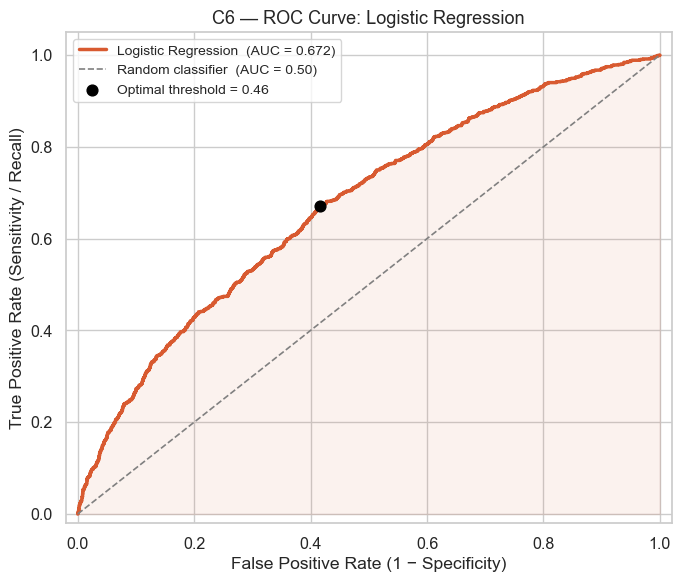

  Saved → ./outputs/phase3/block_c/C6_roc_curve.png

  Optimal classification threshold: 0.464
  At this threshold — TPR: 0.671  FPR: 0.415

C7: Plotting confusion matrix...


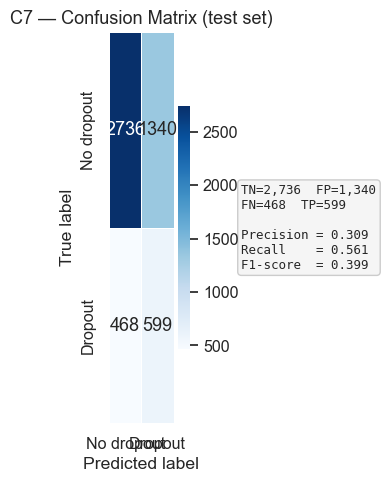

  Saved → ./outputs/phase3/block_c/C7_confusion_matrix.png

BLOCK C COMPLETE — Logistic Regression Results

  Model performance:
    Accuracy    : 64.8%
    ROC-AUC     : 0.6723
    CV AUC      : 0.6690 ± 0.0081

  Significant predictors (p < 0.05):
    • Gender (M=1)
    • Prior education
    • Disability status
    • Studied credits
    • Mean assess. score

  Confusion matrix (test set):
    True Positives  (caught dropouts)  : 599
    False Negatives (missed dropouts)  : 468
    True Negatives  (correct non-drop) : 2,736
    False Positives (false alarms)     : 1,340

  Charts saved to: ./outputs/phase3/block_c/
    C6_roc_curve.png
    C7_confusion_matrix.png
    C5_coefficient_table.csv

─────────────────────────────────────────────────────────
Next → Run phase3_block_d_odds_ratios.py
─────────────────────────────────────────────────────────

  Saved model objects → block_c_objects.pkl  (used by Block D)



In [1]:
"""
=============================================================
Phase 3 — Block C: Logistic Regression
=============================================================
Goal: Identify which features are significant INDEPENDENT
      predictors of dropout after controlling for all other
      variables simultaneously.

Why logistic regression?
  Our target variable (dropout) is binary (0 or 1).
  Linear regression is not appropriate for binary outcomes.
  Logistic regression models the LOG-ODDS of dropout as a
  linear combination of features:

    log(p / 1-p) = β0 + β1x1 + β2x2 + ... + βnxn

  Where:
    p        = probability of dropout
    β0       = intercept (baseline log-odds)
    β1..βn   = coefficients (how much each feature shifts log-odds)

Why multivariate (not just many univariate models)?
  Blocks A and B tested each feature in isolation.
  Two features may both correlate with dropout simply because
  they correlate WITH EACH OTHER (confounding).
  Multivariate logistic regression controls for all features
  simultaneously — so each coefficient reflects the feature's
  UNIQUE contribution.

Steps in this block:
  C1 — Feature engineering and encoding
  C2 — Train/test split
  C3 — Fit logistic regression model
  C4 — Evaluate model performance
  C5 — Coefficient table with p-values and confidence intervals
  C6 — ROC curve
  C7 — Confusion matrix
"""

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
import statsmodels.api as sm   # for p-values and confidence intervals

# ── Config ────────────────────────────────────────────────────
DATA_PATH   = './data/'
OUTPUT_PATH = './outputs/phase3/block_c/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

COLORS = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'coral':  '#D85A30',
    'gray':   '#888780',
    'purple': '#7F77DD',
    'amber':  '#BA7517',
}
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

RANDOM_STATE = 42   # ensures reproducibility

# ── Load data ─────────────────────────────────────────────────
si = pd.read_csv(DATA_PATH + 'studentInfo.csv')
sa = pd.read_csv(DATA_PATH + 'studentAssessment.csv')
si['dropout'] = (si['final_result'] == 'Withdrawn').astype(int)

# Merge mean assessment score
mean_scores = (
    sa.groupby('id_student')['score']
      .mean()
      .reset_index()
      .rename(columns={'score': 'mean_score'})
)
si = si.merge(mean_scores, on='id_student', how='left')

print(f"Loaded studentInfo: {si.shape[0]:,} rows")
print(f"Overall dropout rate: {si['dropout'].mean()*100:.1f}%\n")


# =============================================================
# C1: Feature engineering and encoding
# =============================================================
# We encode every categorical feature as a number so sklearn
# can work with it. We use the same encoding scheme as Block C
# in Phase 2 for consistency.

print("C1: Encoding features...")

df = si.copy()

# ── Ordinal encodings ─────────────────────────────────────────
edu_map = {
    'No Formal quals': 0, 'Lower Than A Level': 1,
    'A Level or Equivalent': 2, 'HE Qualification': 3,
    'Post Graduate Qualification': 4
}
imd_map = {
    '0-10%': 0, '10-20': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9
}
age_map = {'0-35': 0, '35-55': 1, '55<=': 2}

df['edu_enc']      = df['highest_education'].map(edu_map)
df['imd_enc']      = df['imd_band'].map(imd_map)
df['age_enc']      = df['age_band'].map(age_map)
df['gender_enc']   = (df['gender'] == 'M').astype(int)
df['disab_enc']    = (df['disability'] == 'Y').astype(int)

# ── Feature list ──────────────────────────────────────────────
# These are the features we pass to the model.
# We include all features that passed significance in Blocks A/B,
# plus studied_credits as a control variable.
FEATURES = [
    'gender_enc',
    'age_enc',
    'edu_enc',
    'imd_enc',
    'disab_enc',
    'num_of_prev_attempts',
    'studied_credits',
    'mean_score',
]

FEATURE_LABELS = {
    'gender_enc':          'Gender (M=1)',
    'age_enc':             'Age band',
    'edu_enc':             'Prior education',
    'imd_enc':             'IMD band (deprivation)',
    'disab_enc':           'Disability status',
    'num_of_prev_attempts':'Prev. attempts',
    'studied_credits':     'Studied credits',
    'mean_score':          'Mean assess. score',
}

TARGET = 'dropout'

# Drop rows with ANY missing value across our feature set
df_model = df[FEATURES + [TARGET]].dropna()
n_dropped = len(df) - len(df_model)

print(f"  Rows after dropping missing values: {len(df_model):,}  ({n_dropped:,} dropped)")
print(f"  Dropout rate in model dataset: {df_model[TARGET].mean()*100:.1f}%")
print(f"  Features: {FEATURES}\n")


# =============================================================
# C2: Train / test split
# =============================================================
# We split 80% train / 20% test using stratification.
# Stratification ensures both splits have the same ~30% dropout
# rate — important for imbalanced targets.

X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y          # preserve class balance in both splits
)

print(f"C2: Train/test split:")
print(f"  Train : {len(X_train):,} rows  (dropout rate: {y_train.mean()*100:.1f}%)")
print(f"  Test  : {len(X_test):,}  rows  (dropout rate: {y_test.mean()*100:.1f}%)\n")

# ── Scale features ────────────────────────────────────────────
# Logistic regression is sensitive to feature scale.
# StandardScaler transforms each feature to mean=0, std=1.
# We fit the scaler ONLY on training data to avoid data leakage.
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)       # use the same scaler, don't refit


# =============================================================
# C3: Fit logistic regression (statsmodels — for p-values)
# =============================================================
# sklearn's LogisticRegression does not provide p-values or
# confidence intervals. We use statsmodels for the inference
# table, then sklearn for performance metrics and the ROC curve.

print("C3: Fitting logistic regression (statsmodels)...")

# statsmodels requires us to add a constant (intercept) manually
X_train_sm = sm.add_constant(X_train_sc)
X_test_sm  = sm.add_constant(X_test_sc)

# Fit the logistic regression model
logit_model = sm.Logit(y_train, X_train_sm)
result      = logit_model.fit(disp=0)   # disp=0 suppresses iteration output

print(result.summary2())
print()


# =============================================================
# C4: Model evaluation (sklearn)
# =============================================================
# We use sklearn for performance metrics since it integrates
# cleanly with cross-validation and ROC curve tools.

print("C4: Evaluating model performance...")

# Fit sklearn model for predictions
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight='balanced'    # compensate for class imbalance (~30/70 split)
)
lr_model.fit(X_train_sc, y_train)

# Predictions
y_pred       = lr_model.predict(X_test_sc)
y_pred_proba = lr_model.predict_proba(X_test_sc)[:, 1]   # probability of dropout

# Core metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_pred_proba)

print(f"  Accuracy  : {accuracy*100:.1f}%")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print()
print("  Classification report:")
print(classification_report(y_test, y_pred,
                             target_names=['No dropout', 'Dropout']))

# 5-fold stratified cross-validation AUC
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(lr_model, X_train_sc, y_train,
                         cv=cv, scoring='roc_auc')
print(f"  5-fold CV AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print()


# =============================================================
# C5: Coefficient table with p-values and confidence intervals
# =============================================================
# Extract from statsmodels result and build a clean readable table.

print("C5: Building coefficient table...")

coef_df = pd.DataFrame({
    'Feature':   ['Intercept'] + [FEATURE_LABELS[f] for f in FEATURES],
    'Coef (β)':  result.params.values,
    'Std Error': result.bse.values,
    'z-stat':    result.tvalues.values,
    'p-value':   result.pvalues.values,
    'CI lower':  result.conf_int().iloc[:, 0].values,
    'CI upper':  result.conf_int().iloc[:, 1].values,
})

# Round for display
coef_df = coef_df.round(4)

# Add significance stars
def sig_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01:  return '**'
    elif p < 0.05:  return '*'
    else:           return 'n.s.'

coef_df['Sig'] = coef_df['p-value'].apply(sig_stars)

print("\n  Coefficient table (features only, excluding intercept):")
print(coef_df[coef_df['Feature'] != 'Intercept'][[
    'Feature', 'Coef (β)', 'Std Error', 'z-stat', 'p-value', 'Sig',
    'CI lower', 'CI upper'
]].to_string(index=False))
print()
print("  Significance codes: *** p<0.001  ** p<0.01  * p<0.05  n.s. not significant")
print()

# Save the coefficient table as CSV for the portfolio
coef_path = os.path.join(OUTPUT_PATH, "C5_coefficient_table.csv")
coef_df.to_csv(coef_path, index=False)
print(f"  Saved → {coef_path}\n")


# =============================================================
# C6: ROC curve
# =============================================================
# The ROC (Receiver Operating Characteristic) curve plots:
#   x-axis: False Positive Rate = FP / (FP + TN)
#   y-axis: True  Positive Rate = TP / (TP + FN)  (= Recall)
#
# A perfect model hugs the top-left corner. AUC = 1.0.
# A random model follows the diagonal. AUC = 0.5.
# Our target is AUC > 0.70 for a useful early warning model.

print("C6: Plotting ROC curve...")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color=COLORS['coral'], linewidth=2.5,
        label=f'Logistic Regression  (AUC = {roc_auc:.3f})')
ax.fill_between(fpr, tpr, alpha=0.08, color=COLORS['coral'])

# Random baseline
ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        linewidth=1.2, label='Random classifier  (AUC = 0.50)')

# Mark the point closest to (0, 1) — optimal threshold
optimal_idx   = np.argmax(tpr - fpr)
optimal_fpr   = fpr[optimal_idx]
optimal_tpr   = tpr[optimal_idx]
optimal_thresh = thresholds[optimal_idx]

ax.scatter(optimal_fpr, optimal_tpr, color='black',
           zorder=5, s=60, label=f'Optimal threshold = {optimal_thresh:.2f}')

ax.set_title("C6 — ROC Curve: Logistic Regression", fontsize=13)
ax.set_xlabel("False Positive Rate (1 − Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)")
ax.legend(fontsize=10)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "C6_roc_curve.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")
print(f"  Optimal classification threshold: {optimal_thresh:.3f}")
print(f"  At this threshold — TPR: {optimal_tpr:.3f}  FPR: {optimal_fpr:.3f}\n")


# =============================================================
# C7: Confusion matrix
# =============================================================
# Shows how the model's predictions break down:
#   True Positive  (TP): predicted dropout,   actually withdrew
#   True Negative  (TN): predicted no dropout, actually completed
#   False Positive (FP): predicted dropout,   actually completed  (false alarm)
#   False Negative (FN): predicted no dropout, actually withdrew  (missed dropout)
#
# For an early warning system, False Negatives are the most costly
# (students we missed who then dropped out). We want high Recall.

print("C7: Plotting confusion matrix...")

cm = confusion_matrix(y_test, y_pred)
cm_labels = ['No dropout', 'Dropout']

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues',
    xticklabels=cm_labels,
    yticklabels=cm_labels,
    ax=ax,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 13}
)

ax.set_title("C7 — Confusion Matrix (test set)", fontsize=13)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

# Annotate TN, FP, FN, TP
tn, fp, fn, tp = cm.ravel()
annotation_text = (
    f"TN={tn:,}  FP={fp:,}\n"
    f"FN={fn:,}  TP={tp:,}\n\n"
    f"Precision = {tp/(tp+fp):.3f}\n"
    f"Recall    = {tp/(tp+fn):.3f}\n"
    f"F1-score  = {2*tp/(2*tp+fp+fn):.3f}"
)
ax.text(2.05, 0.5, annotation_text, transform=ax.transAxes,
        fontsize=9, va='center', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#F5F5F5', edgecolor='#CCCCCC'))

plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "C7_confusion_matrix.png")
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# BLOCK C SUMMARY
# =============================================================
sig_features = coef_df[
    (coef_df['Feature'] != 'Intercept') &
    (coef_df['p-value'] < 0.05)
]['Feature'].tolist()

print("=" * 60)
print("BLOCK C COMPLETE — Logistic Regression Results")
print("=" * 60)
print(f"""
  Model performance:
    Accuracy    : {accuracy*100:.1f}%
    ROC-AUC     : {roc_auc:.4f}
    CV AUC      : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}

  Significant predictors (p < 0.05):
{chr(10).join(f'    • {f}' for f in sig_features)}

  Confusion matrix (test set):
    True Positives  (caught dropouts)  : {tp:,}
    False Negatives (missed dropouts)  : {fn:,}
    True Negatives  (correct non-drop) : {tn:,}
    False Positives (false alarms)     : {fp:,}

  Charts saved to: {OUTPUT_PATH}
    C6_roc_curve.png
    C7_confusion_matrix.png
    C5_coefficient_table.csv

─────────────────────────────────────────────────────────
Next → Run phase3_block_d_odds_ratios.py
─────────────────────────────────────────────────────────
""")

# Save key objects for Block D
import pickle
with open(os.path.join(OUTPUT_PATH, 'block_c_objects.pkl'), 'wb') as f:
    pickle.dump({
        'result':       result,
        'coef_df':      coef_df,
        'FEATURES':     FEATURES,
        'FEATURE_LABELS': FEATURE_LABELS,
        'roc_auc':      roc_auc,
        'accuracy':     accuracy,
    }, f)
print("  Saved model objects → block_c_objects.pkl  (used by Block D)\n")